In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np

In [2]:
data = pd.read_csv("C:\Study content\ML\DATASETS\Rainfall Prediction.csv")
print(data.describe())

           tempmax      tempmin         temp  feelslikemax  feelslikemin  \
count  1664.000000  1664.000000  1664.000000   1664.000000   1664.000000   
mean     80.871094    60.095012    69.791827     82.424700     59.345012   
std      15.074327    14.748907    14.351736     17.125754     16.120580   
min      22.600000     8.200000    15.700000     12.800000     -7.100000   
25%      71.500000    47.900000    58.900000     71.500000     46.200000   
50%      82.500000    62.950000    71.900000     83.000000     62.950000   
75%      92.800000    73.700000    82.300000     97.525000     73.700000   
max     107.900000    82.900000    92.300000    117.000000     90.700000   

         feelslike          dew     humidity       precip   precipprob  ...  \
count  1664.000000  1664.000000  1664.000000  1664.000000  1664.000000  ...   
mean     70.424519    55.555168    64.579567     0.084632    28.245192  ...   
std      16.284259    15.161742    13.449047     0.304253    45.032733  ...   

In [3]:
features = ['tempmax', 'tempmin', 'humidity', 'dew']
target = 'precip'
data = data.dropna(subset=features + [target])

In [4]:
X= data[features]
Y = data[target]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
y_pred = model.predict(X_test)

In [8]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2= r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 0.049747708518265
Root Mean Squared Error: 0.2230419434058648
R^2 Score: 0.16619844427894748


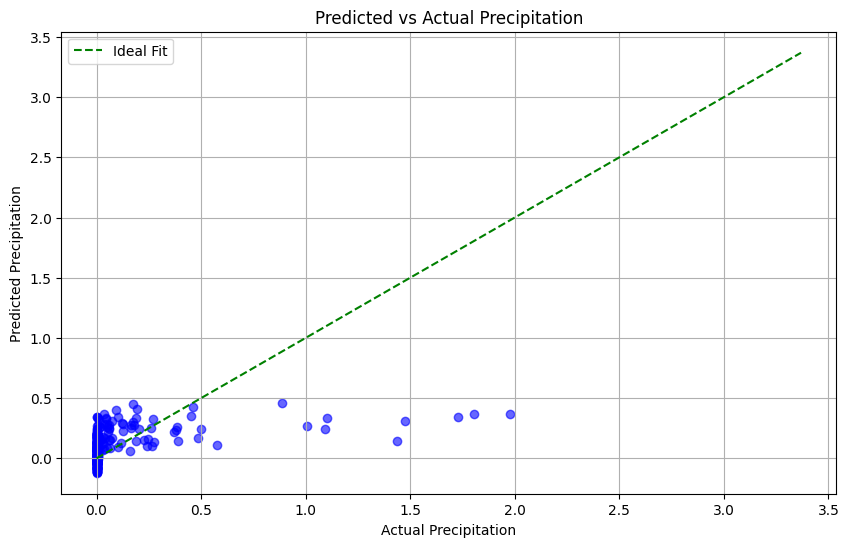

In [19]:
plt.figure(figsize=(10,6))
plt.scatter(y_test,y_pred, color='blue', alpha=0.6)
plt.plot([Y.min(),Y.max()],[Y.min(),Y.max()], color='green', label='Ideal Fit',linestyle='--')
plt.title('Predicted vs Actual Precipitation')
plt.xlabel('Actual Precipitation')
plt.ylabel('Predicted Precipitation')
plt.legend()
plt.grid()
plt.show()

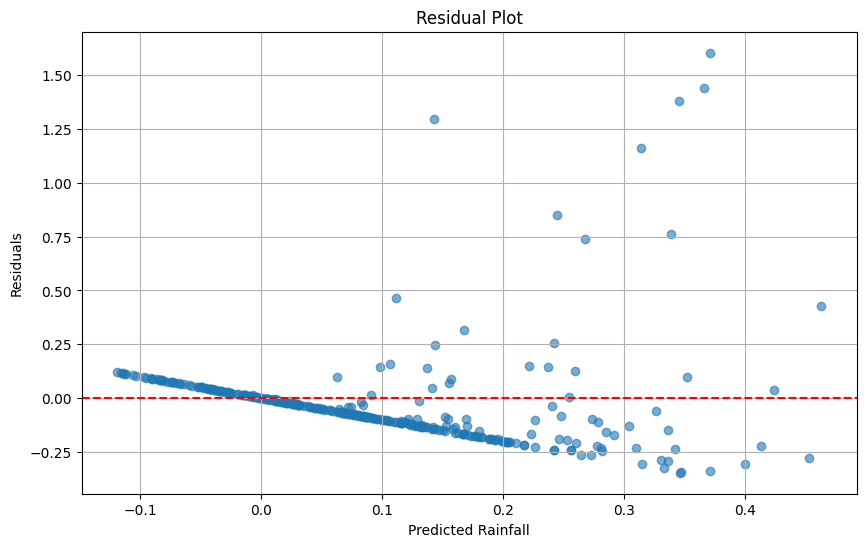

In [17]:
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Rainfall')
plt.ylabel('Residuals')
plt.grid()
plt.show()